In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
import platform
import subprocess
import json
from io import StringIO
import numpy as np
import pandas as pd
from pathlib import Path


from html_from_assignments import NMRProblem
import jsonUtils

import nmrsolution
# from globals import svgDimensions

import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw

In [5]:
%matplotlib inline

In [6]:
platform.system()

'Windows'

In [7]:
if platform.system() == "Darwin":

    fn_json = Path("/Users/vsmw51/Downloads/4Eric/caryophyllene/caryophyllene_assignments_mresnova.json")
    fn_json = Path("/Users/vsmw51/Downloads/4Eric/caryophyllene/caryophyllene_assignments_mresnova.json")
    fn_json = Path("/Users/vsmw51/OneDrive - Durham University/projects/programming/2025/python/awh/bruker_data_sets/E72507_04164043_propyl_benzoate/04164043/04164043_assignments.json")
    fn_json = Path("/opt/topspin4.5.0/examdata/exam_CMCse_1/exam_CMCse_1_assignments.json")

elif platform.system() == "Windows":
    fn_json = Path(r"C:\Users\vsmw51\OneDrive - Durham University\projects\programming\2025\python\awh\bruker_data_sets\E72507_04164043_propyl_benzoate\04164043\04164043_jeol_inputdata.json")
    

In [55]:
with open(fn_json, 'r') as f:
    json_data = json.load(f)

In [57]:
json_data.keys()

dict_keys(['smiles', 'molfile', 'hostname', 'workingDirectory', 'workingFilename', 'MNOVAcalcMethod', 'carbonCalcPositionsMethod', 'allAtomsInfo', 'carbonAtomsInfo', 'c13predictions', 'chosenSpectra', 'spectraWithPeaks', 'simulatedAnnealing', 'ml_consent', 'SKIP_0', 'HSQC_0'])

In [61]:
json_data['molfile']['data']['0']

'\n     RDKit          2D\n\n 12 12  0  0  0  0  0  0  0  0999 V2000\n    8.3438    1.8827    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    7.1314    1.1827    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    5.9189    1.8827    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    4.7065    1.1827    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0\n    3.4940    1.8827    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    3.4940    3.2827    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0\n    2.2816    1.1827    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    1.0692    1.8827    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   -0.1433    1.1827    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   -0.1433   -0.2173    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    1.0692   -0.9173    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    2.2816   -0.2173    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n  1  2  1  0\n  2  3  1  0\n  3  4  1  0\n  4  5  1  0\n  5  6  2  0\n  5  7  

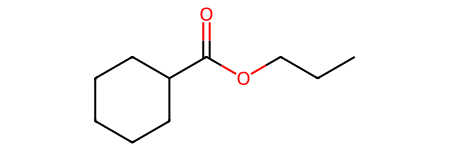

In [63]:
Chem.MolFromMolBlock(json_data['molfile']['data']['0'])

In [9]:
problemdata_json = NMRProblem.from_mnova_dict(json_data)


from_mnova_dict(cls,json_data: dict):

Processing key: smiles
	data[smiles].keys()
 dict_keys(['datatype', 'count', 'data']) 

v.items():
 dict_items([('datatype', 'smiles'), ('count', 1), ('data', {'0': 'CCCOC(=O)C1CCCCC1'})]) 

Processing key: molfile
	data[molfile].keys()
 dict_keys(['datatype', 'count', 'data']) 

v.items():
 dict_items([('datatype', 'molfile'), ('count', 1), ('data', {'0': '\n     RDKit          2D\n\n 12 12  0  0  0  0  0  0  0  0999 V2000\n    8.3438    1.8827    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    7.1314    1.1827    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    5.9189    1.8827    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    4.7065    1.1827    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0\n    3.4940    1.8827    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    3.4940    3.2827    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0\n    2.2816    1.1827    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    1.0692    1.8827    0.0000 C  

In [10]:
solution = nmrsolution.NMRsolution(problemdata_json)

self.expts_available {'HSQC', 'SKIP'}
problemdata_json.dataframes.keys() dict_keys(['smiles', 'molfile', 'workingDirectory', 'workingFilename', 'MNOVAcalcMethod', 'carbonCalcPositionsMethod', 'allAtomsInfo', 'carbonAtomsInfo', 'c13predictions', 'chosenSpectra', 'spectraWithPeaks', 'simulatedAnnealing', 'nmrAssignments', 'molecule', 'HSQC', 'H1_1D', 'C13_1D', 'DEPT135', 'H1_pureshift', 'COSY', 'HSQC_CLIPCOSY', 'DDEPT_CH3_ONLY', 'HMBC', 'NOESY'])
self.c13_df
 Empty DataFrame
Columns: [ppm, intensity, Width, Area, signaltype, Flags, Impurity/Compound, Annotation]
Index: []
Prediction from JEOL
Prediction from JEOL
BEFORE ::: self.molprops_df
    idx  atom_idx  implicitHs  totalNumHs  degree  hybridization  aromatic
0    0         0           3           3       1              4     False
1    1         1           2           2       2              4     False
2    2         2           2           2       2              4     False
3    4         4           0           0       3        

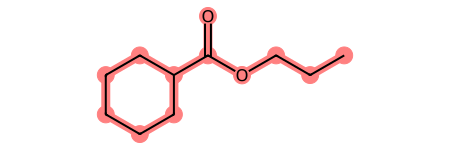

In [11]:
solution.expected_molecule

In [12]:
solution.nmrsolution_failed

False

In [13]:
solution.expected_molecule.nmrshiftdb_failed

False

In [14]:
solution.c13_df

,ppm,intensity,Width,Area,signaltype,Flags,Impurity/Compound,Annotation


In [15]:
solution.hsqc_df

,f2_ppm,f1_ppm,intensity,signaltype,Annotation
1,8.076889,129.612369,206417779.0,0,
2,7.564806,132.837341,178473625.0,0,
3,7.455533,128.389104,87251112.0,0,
4,4.307229,66.601487,-351086109.0,0,
5,1.815463,22.150359,-92852235.0,0,
6,1.056902,10.555817,381354534.0,0,


In [17]:
ok, msg = solution.init_class_from_json()

self.HSQC_data_present: True
self.hsqc_df:
      f2_ppm      f1_ppm    intensity  signaltype Annotation
1  8.076889  129.612369  206417779.0           0           
2  7.564806  132.837341  178473625.0           0           
3  7.455533  128.389104   87251112.0           0           
4  4.307229   66.601487 -351086109.0           0           
5  1.815463   22.150359  -92852235.0           0           
6  1.056902   10.555817  381354534.0           0           
p0 66.60148654530168 <class 'float'>
p0 22.15035915084674 <class 'float'>
init_c13_from_hsqc_and_hmbc
init_pureshift_from_h1
self.C13indexC13ppm {1: 132.83734114266346, 2: 129.6123692477328, 3: 128.3891040462074, 4: 66.60148654530168, 5: 22.15035915084674, 6: 10.555817338126023}
1
2
3
4
5
6
Assigning f1p_ppm and f1p_i to h1 dataframe based on hsqc dataframe
self.h1.:
         ppm  integral  numProtons jCouplingClass jCouplingVals label f1H_i  \
1  8.076889        -1          -1                                 H1    H1   
2  7.5648

C:\Users\vsmw51\OneDrive - Durham University\projects\programming\2025\python\awh\simpleNMRtools2\nmrsolution.py:1463: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '159.57691216057307' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[idx, f"{column_name}_prob"] = stats.norm.pdf(
C:\Users\vsmw51\OneDrive - Durham University\projects\programming\2025\python\awh\simpleNMRtools2\nmrsolution.py:1463: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '79.78845608028654' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[idx, f"{column_name}_prob"] = stats.norm.pdf(
C:\Users\vsmw51\OneDrive - Durham University\projects\programming\2025\python\awh\simpleNMRtools2\nmrsolution.py:2269: FutureWarning: Setting an item of incompatible dtype is deprec

In [18]:
ok

True

In [19]:
msg

'ok'

In [21]:
solution.hsqc.columns


Index(['f2_ppm', 'f1_ppm', 'intensity', 'signaltype', 'Annotation', 'f1_i',
       'f2_i', 'f2p_i', 'f1C_i', 'f2H_i', 'f2Cp_i', 'f2p_ppm', 'CH2', 'CH3CH1',
       'CH3', 'CH1', 'CH0', 'quaternary', 'numProtons', 'attached_protons',
       'f2_integral', 'f1_ppm_orig', 'f1_ppm_prob', 'f2_ppm_orig',
       'f2_ppm_prob'],
      dtype='object')

In [25]:
solution.hsqc[['f2_ppm', 'f1_ppm', 'numProtons', 'CH0', 'CH1', 'CH2', 'CH3', 'CH3CH1']]

,f2_ppm,f1_ppm,numProtons,CH0,CH1,CH2,CH3,CH3CH1
1,8.076889,129.612369,-1,False,False,False,False,False
2,7.564806,132.837341,-1,False,False,False,False,False
3,7.455533,128.389104,-1,False,False,False,False,False
4,4.307229,66.601487,-1,False,False,True,False,False
5,1.815463,22.150359,-1,False,False,True,False,False
6,1.056902,10.555817,-1,False,False,False,False,False


In [26]:
dir(solution)

['C13_data_missing',
 'C13_data_present',
 'C13indexC13label',
 'C13indexC13ppm',
 'C13labelC13index',
 'C13labelC13ppm',
 'C13ppmC13index',
 'C13ppmC13label',
 'COSY_data_missing',
 'COSY_data_present',
 'DDEPT_CH3_ONLY_data_missing',
 'DDEPT_CH3_ONLY_data_present',
 'DEPT_data_missing',
 'DEPT_data_present',
 'H1_data_missing',
 'H1_data_present',
 'H1indexH1label',
 'H1indexH1ppm',
 'H1labelH1index',
 'H1labelH1ppm',
 'H1ppmH1index',
 'H1ppmH1label',
 'HMBC_data_missing',
 'HMBC_data_present',
 'HSQC_CLIPCOSY_data_missing',
 'HSQC_CLIPCOSY_data_present',
 'HSQC_data_missing',
 'HSQC_data_present',
 'NOESY_data_missing',
 'NOESY_data_present',
 'PURESHIFT_data_missing',
 'PURESHIFT_data_present',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__'

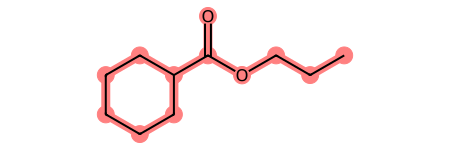

In [29]:
solution.expected_molecule

In [32]:
solution.expected_molecule.molprops_df.columns

Index(['atom_idx', 'atomNumber', 'numProtons_x', 'ppm', 'implicitHs',
       'totalNumHs', 'degree', 'hybridization', 'aromatic', 'numProtons_y',
       'quaternary', 'CH0', 'CH1', 'CH2', 'CH3', 'CH3CH1', 'picked',
       'numProtons', 'ring_idx', 'ring_size', 'ring_idx0', 'ring_size0', 'x',
       'y', 'symmetry_idx1', 'symmetry_idx2', 'sym_atom_idx',
       'sym_atomNumber'],
      dtype='object')

In [54]:
solution.expected_molecule.molprops_df[['ppm', 'atomNumber', 'numProtons', 'totalNumHs', 'implicitHs', 'CH0', 'CH1', 'CH2', 'CH3', 'CH3CH1', 'sym_atomNumber']]

,ppm,atomNumber,numProtons,totalNumHs,implicitHs,CH0,CH1,CH2,CH3,CH3CH1,sym_atomNumber
idx,,,,,,,,,,,
0,10.463333,1,3,3,3,False,False,False,True,True,
1,22.139999,2,2,2,2,False,False,True,False,False,
2,66.513336,3,2,2,2,False,False,True,False,False,
4,166.922089,5,0,0,0,True,False,False,False,False,
9,133.570618,10,1,2,2,False,False,True,False,False,
6,130.183060,7,0,1,1,False,True,False,False,True,
7,129.609238,8,1,2,2,False,False,True,False,False,12
11,129.609238,12,1,2,2,False,False,True,False,False,8
8,128.416153,9,1,2,2,False,False,True,False,False,11


In [28]:
dir(solution.expected_molecule)

['GetAromaticAtoms',
 'GetAtomWithIdx',
 'GetAtoms',
 'GetBondBetweenAtoms',
 'GetBondWithIdx',
 'GetBonds',
 'GetConformer',
 'GetNumAtoms',
 'GetNumBonds',
 'GetRingInfo',
 'GetRingSystems',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_repr_png_',
 '_repr_svg_',
 'add_ring_info_to_dataframe',
 'c13_nmr_shifts',
 'calc_allatom_xy_positions_png',
 'calc_carbon_xy_positions_png',
 'calc_dbe',
 'calculated_c13_chemical_shifts',
 'copy_xy3_to_molecule',
 'create_png',
 'create_svg_string',
 'dbe',
 'elements',
 'has_hose_code_symmetry',
 'has_symmetry',
 'init_elements_dict',
 'map_symmetric_aromatic_rings',
 'mapped_symmetric_aromatic_rings',
 'mol'

In [39]:
rtn_msg, rtn_num = solution.assign_CH3_CH2_CH1_overall()

assign_CH3_CH2_CH1_in_HSQC_using_Assignments
c13_from_hsqc and H1_data_missing
CH1_mol_df.shape[0]: 1
num_CH3CH1_hsqc: 4
CH3CH1_hsqc_df.shape[0]: 4
CH3CH1_mol_df.shape[0]: 2
CH3CH1_sym_mol_df.shape[0]: 2
more CH3CH1 groups in HSQC than expected molecule, this is a problem
solution failed
CH3CH1 HSQC > CH3CH1 expected molecule 400


In [38]:
ok

True

In [40]:
solution.assign_CH3_CH2_CH1_in_HSQC_using_Assignments()

assign_CH3_CH2_CH1_in_HSQC_using_Assignments


In [42]:
solution.hsqc[['f2_ppm', 'f1_ppm', 'numProtons', 'CH0', 'CH1', 'CH2', 'CH3', 'CH3CH1']]

,f2_ppm,f1_ppm,numProtons,CH0,CH1,CH2,CH3,CH3CH1
1,8.076889,129.612369,-1,False,False,False,False,True
2,7.564806,132.837341,-1,False,False,False,False,True
3,7.455533,128.389104,-1,False,False,False,False,True
4,4.307229,66.601487,2,False,False,True,False,False
5,1.815463,22.150359,2,False,False,True,False,False
6,1.056902,10.555817,-1,False,False,False,False,True


In [44]:
solution.assign_CH3_CH1_in_HSQC_using_H1()

In [45]:
solution.hsqc[['f2_ppm', 'f1_ppm', 'numProtons', 'CH0', 'CH1', 'CH2', 'CH3', 'CH3CH1']]

,f2_ppm,f1_ppm,numProtons,CH0,CH1,CH2,CH3,CH3CH1
1,8.076889,129.612369,-1,False,False,False,False,True
2,7.564806,132.837341,-1,False,False,False,False,True
3,7.455533,128.389104,-1,False,False,False,False,True
4,4.307229,66.601487,2,False,False,True,False,False
5,1.815463,22.150359,2,False,False,True,False,False
6,1.056902,10.555817,-1,False,False,False,False,True


In [47]:
solution.assign_CH3_CH1_in_HSQC_using_expected_molecule()

c13_from_hsqc and H1_data_missing
CH1_mol_df.shape[0]: 1
num_CH3CH1_hsqc: 4
CH3CH1_hsqc_df.shape[0]: 4
CH3CH1_mol_df.shape[0]: 2
CH3CH1_sym_mol_df.shape[0]: 2
more CH3CH1 groups in HSQC than expected molecule, this is a problem
